## Runpod Environmental Setup

In [ ]:
!pip install openai
!pip install bert-score
!pip install transformers
!pip install huggingface
!pip install dataset
!pip install accelerate
!pip install --upgrade typing_extensions
!pip install openai
!pip install --upgrade transformers

## Login into HuggingFace

To use the expert and amateur models referenced in the paper, you must first authenticate with Hugging Face. These models are gated and require access approval.

**Required Models**

*  [TinyLlama-1.1B-Chat-v1.0](https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0)

* [LLaMA-3-13B-Instruct](https://huggingface.co/elinas/Llama-3-13B-Instruct)

In [ ]:
from huggingface_hub import login
login(token = "HUGGINGFACE_TOKEN")

## Expert Feedback Model

The `ExpertFeedbackModel` is a feedback-driven answer refinement framework designed to simulate the role of an expert reviewer. It leverages large language models (LLMs)—specifically LLaMA-3-13B-Instruct in the paper—to generate, evaluate, and iteratively improve answers through a combination of self-critique and unified feedback from both expert and amateur models.

This model enables a multi-step refinement process where initial answers are accessed, revised based on feedback, and further enhanced to reach a target quality threshold. By integrating both expert and amateur perspectives, it promotes contrastive reasoning and emphasizes the superiority of expert-driven revisions.

**Core Capabilities**

1. **Answer Generation**

  Produces a response to a given question using structured prompts. This includes generating the initial answer as well as revised versions based on unified feedback and self-critique. The output is designed to maintain clarity, coherence, and adherence to specified word limits.

2. **Feedback Evaluation**

  Evaluates the quality of a given answer, assigning a numerical score and textual justification using a rubric-based prompt

3. **Expert-Amateur Feedback Merging**

  Merges expert and amateur feedback using contrastive reasoning, prioritizing expert insight while incorporating useful amateur points.

4. **Answer Revision**

  Revises the original answer according to the generated feedback and its self-critique, producing a more accurate and coherent response.

5. **Self-Critique**

  Produces a focused 50-word critique explaining why the revised answer is improved

6. Iterative Improvement

  * Gets combined feedback from a network (teacher-student model)

  * Condenses and applies the feedback

  * Self-critique the revision

  * Refines the answer

  * Re-scores the result for final evaluation


The model optionally connects to an external `network` object to retrieve feedback from both expert and amateur perspectives, combining and aligning them toward improved performance.

In [ ]:
import re
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re

def clean_bracketed_notes(text):
    # Remove all [bracketed notes] (trailing or inline)
    return re.sub(r"\s*\[.*?\]", "", text).strip()

def truncate_words(text, max_words):
    words = text.split()
    return " ".join(words[:max_words]) if len(words) > max_words else text

class ExpertFeedbackModel:
    def __init__(self, model_name="elinas/Llama-3-13B-Instruct", network=None):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        if torch.cuda.device_count() > 1:
            print(f"Using {torch.cuda.device_count()} GPUs with DataParallel.")
            self.model = torch.nn.DataParallel(self.model)

        self.model.to(self.device)
        self.network = network

    def generate_text(self, prompt, max_new_tokens=300, temperature=0.3):
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
        model = self.model.module if isinstance(self.model, torch.nn.DataParallel) else self.model

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=temperature,
            top_p=0.5,
            pad_token_id=self.tokenizer.eos_token_id
        )

        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)

    def generate_answer(self, question, max_new_tokens=300, max_words=100):
        prompt = (
            "You are a helpful academic assistant.\n"
            f"Provide a clear and accurate answer to the question below in approximately {max_words} words.\n"
            "Respond with a single answer only—no multiple Q&As.\n\n"
            "When you have finished your sentence, please write [Stop]\n"
            f"Question: {question}\n\nAnswer:"
        )

        response = self.generate_text(prompt, max_new_tokens)
        answer = response.split("Answer:", 1)[-1].strip()

        # Truncate at "[Stop]" if it exists
        answer = answer.split("[Stop]", 1)[0].strip()

        # Remove any leftover bracketed notes
        answer = clean_bracketed_notes(answer)

        # Optionally truncate to max_words
        answer = truncate_words(answer, max_words)

        return answer


    def generate_feedback(self, question, answer):
        prompt = (
            f"Question: {question}\n"
            f"Answer: {answer}\n\n"
            "Evaluate the quality and relevance of the answer in response to the question. "
            "Rate it using the scale below and provide a brief justification for your score:\n\n"
            "  •  1.0 — Excellent: completely correct, clear, and highly relevant\n"
            "  •  0.7 to 0.9 — Good: mostly correct and relevant, with minor issues\n"
            "  •  0.4 to 0.6 — Fair: some useful elements, but has clear problems\n"
            "  •  0.1 to 0.3 — Weak: limited value, vague or largely off-topic\n"
            "  •  0.0 — Not helpful: off-topic, irrelevant, or no useful information\n"
            "  • -0.1 to -0.4 — Misleading: somewhat incorrect or confusing\n"
            "  • -0.5 to -0.9 — Wrong: mostly incorrect or misleading\n"
            "  • -1.0 — Harmful: completely wrong or potentially dangerous\n\n"
            "Respond only in this format:\n"
            "Score: <number>\n"
            "Feedback: <brief justification for the score>"
        )

        response = self.generate_text(prompt, max_new_tokens=200)

        # Extract score
        score_matches = re.findall(r"Score\s*:\s*(-?1(?:\.0+)?|-?0(?:\.\d+)?|-\d\.\d+)", response)
        score = float(score_matches[-1]) if score_matches else 0.0

        # Extract feedback
        feedback_matches = re.findall(r"Feedback\s*:\s*(.*?)(?=\n\S|$)", response, re.DOTALL)
        feedback = feedback_matches[-1].strip() if feedback_matches else "No feedback provided."
        feedback = re.sub(r"(?i)^example\s*:\s*", "", feedback).strip()

        return feedback, score

    def prompt_condense_feedback(self, expert_feedback, amateur_feedback):
        return (
            "You are given two feedback comments on an answer:\n"
            f"- Expert Feedback (trusted): {expert_feedback.strip()}\n"
            f"- Amateur Feedback: {amateur_feedback.strip()}\n\n"
            "Your task is to write a unified feedback summary (max 70 words) that:\n"
            "- Prioritizes insights from the expert feedback\n"
            "- Incorporates any unique and constructive points from the amateur feedback\n"
            "- Resolves disagreements by favoring the expert\n"
            "- Uses contrastive reasoning to emphasize the strengths of the expert feedback\n\n"
            "Final Merged Feedback:"
        )

    def generate_unified_feedback(self, expert_feedback, amateur_feedback):
        full_prompt = self.prompt_condense_feedback(expert_feedback, amateur_feedback)
        response = self.generate_text(full_prompt)

        if "Final Merged Feedback:" in response:
            return response.split("Final Merged Feedback:")[-1].strip()
        return response.strip()

    def apply_feedback(self, question, answer, feedback):
        prompt = (
            "You are an expert writing assistant. Revise the answer below based on the provided feedback. "
            "Ensure the revision is concise, logically organized, and focused. Do not include explanations or commentary.\n\n"
            f"Question: {question}\n"
            f"Original Answer: {answer}\n"
            f"Feedback: {feedback}\n\n"
            "Provide only the revised answer in the following format:\nImproved Answer:"
        )

        response = self.generate_text(prompt)

        if "Improved Answer:" not in response:
            return "[ERROR] No improved answer generated."

        improved_answer = response.rsplit("Improved Answer:", 1)[-1].strip()

        if not improved_answer:
            return "[ERROR] Empty improved answer."

        # Take only the first paragraph
        first_paragraph = improved_answer.split("\n\n")[0].split("\n")[0].strip()
        return clean_bracketed_notes(first_paragraph)

    def generate_self_critique(self, question, answer):
        prompt = (
            "You are an expert evaluator. Write a concise, 50-word critique explaining why the revised answer is an improvement.\n"
            "Focus on clarity, motivation, tone, and detail. Avoid repeating phrases like 'more effective.' Use varied language and be specific.\n\n"
            f"Question:\n{question}\n\nRevised Answer:\n{answer}\n\nCritique (exactly 50 words):"
        )
        response = self.generate_text(prompt, max_new_tokens=100)
        return response.split("Critique (exactly 50 words):", 1)[-1].strip()

    def improve_answer_with_feedback_and_critique(self, question, answer, target_score=1.0):
        # Step 1: Get initial feedback (use dummy values here or hook into self.network)
        original_feedback_dict = self.network.generate_combined_feedback(question, answer)

        expert_feedback = original_feedback_dict.get("expert_feedback", "")
        amateur_feedback = original_feedback_dict.get("amateur_feedback", "")
        initial_score = float(original_feedback_dict.get("combined_score", -1.0))

        if initial_score >= target_score:
            return answer.strip(), initial_score, False  # No improvement needed

        # Step 2: Merge feedback
        condensed_feedback = self.generate_unified_feedback(expert_feedback, amateur_feedback)
        feedback_paragraph = condensed_feedback.strip().split('\n\n')[0].strip()
        print(f"Condensed: {feedback_paragraph}")

        # Step 3: First revision
        improved = self.apply_feedback(question, answer, feedback_paragraph)
        print(f"Improved: {improved}")

        # Step 4: Self-critique the improvement
        critique = self.generate_self_critique(question, improved)

        # Step 5: Refine the improved answer using the critique
        refined = self.apply_feedback(question, improved, critique)
        print(f"Refined: {refined}")

        # Step 6: Final feedback simulation (replace with real feedback if needed)
        final_feedback_dict = self.network.generate_combined_feedback(question, refined, KD=False)
        final_score = float(final_feedback_dict.get("combined_score", -1.0))

        return refined.strip(), final_score, True


In [ ]:
# Define the question first
question = "Why do you want to become a machine learning engineer?"

# Instantiate the model
expert_model = ExpertFeedbackModel()

# Generate the answer
answer = expert_model.generate_answer(question)

# # Improve the answer (assuming this method exists in your class)
# improved_answer, final_score, was_improved = expert_model.improve_answer_with_feedback_and_critique(
#     question, answer, target_score=0.8
# )

# print("--- Result ---")
# print(answer)
# print(improved_answer)

In [ ]:
print(answer)

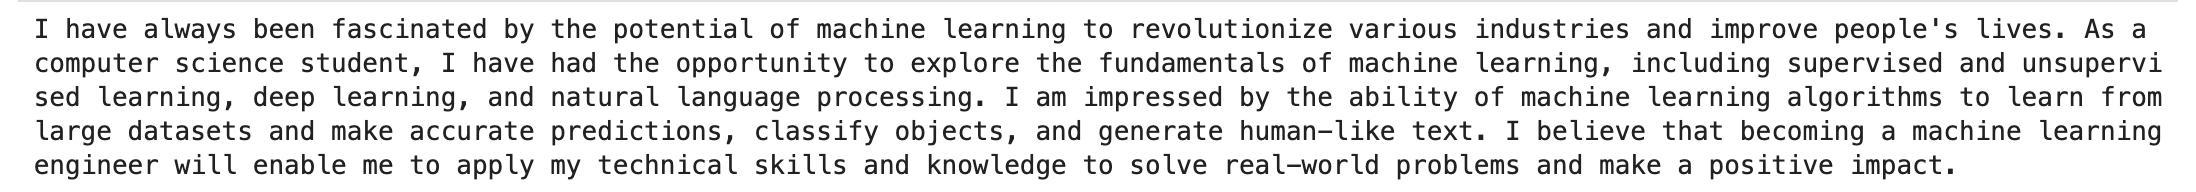

In [ ]:
feedback, score = expert_model.generate_feedback(question, answer)

## DataSet Loading

### Sample Dataset Entry

**Prompt:**  
`who are the basques and where do they live`

**Original Answer:**  
> The Basques (/bɑːsks/ or /bæsks/; Basque: euskaldunak; Spanish: vascos; French: basques) are an indigenous ethnic group characterized by the Basque language, a common culture, and shared ancestry to the ancient Vascones and Aquitanians.  
> They primarily inhabit the Basque Country (Euskal Herria), a region around the western end of the Pyrenees, straddling parts of north-central Spain and southwestern France.

**Score:** `1.0`

**Feedback:**  
> The answer is accurate, complete, and well-written. It provides a detailed explanation of who the Basques are...  

**Improved Answer:**  
> The Basques are an indigenous ethnic group primarily living in the Basque Country... They are characterized by their unique language, Basque, and a shared ancestry tracing back to the ancient Vascones and Aquitanians.


-> [1k_dataset.jsonl](https://drive.google.com/file/d/1YHlMR4-3XwrSlX-S5ohnkITL3wyLaFXZ/view?usp=sharing)

In [ ]:
import json

file_path = "1k_dataset.jsonl"
expert_datasets = []

with open(file_path, "r") as f:
    for line in f:
        item = json.loads(line)

        prompt = item["prompt"]
        original_answer = item["original_answer"]
        score = item["score"]
        feedback = item["feedback"]
        expert_datasets.append(
            {"prompt": prompt,
             "answer": original_answer,
             "feedback": feedback,
             "score": score}
        )

print(f" {len(expert_datasets)} examples loaded")

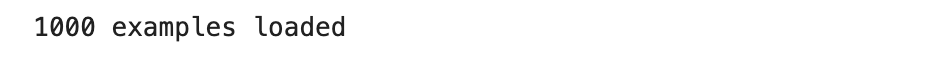

## Amateur Feedback Model

The `AmateurFeedbackModel` is a lightweight, feedback-generating model that simulates a novice reviewer by leveraging TinyLlama-1.1B-Chat-v1.0. It is designed to generate answer evaluations and learn from expert-labeled data, supporting training loops in knowledge distillation.


**Core Capabilities**

**Feedback Generation**
  Given a question and its answer, the model evaluates the response and outputs:
  
  * A numerical score (from -1.0 to 1.0)

  * A brief justification: this simulates an amateur's perspective on quality and relevance.

In [ ]:
import re
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

try:
    from bert_score import score as bert_score  # optional
except ImportError:
    bert_score = None


class AmateurFeedbackModel:
    def __init__(self, model_name="TinyLlama/TinyLlama-1.1B-Chat-v1.0", network=None, device=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Load model and tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)

        if torch.cuda.device_count() > 1:
            print(f"Using {torch.cuda.device_count()} GPUs with DataParallel.")
            self.model = torch.nn.DataParallel(self.model)

        self.model.to(self.device)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model_dtype = next(self.model.parameters()).dtype

        self.network = network
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=2e-5)

    def generate_text(self, prompt, max_new_tokens=300, temperature=0.3):
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
        model = self.model.module if isinstance(self.model, torch.nn.DataParallel) else self.model

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=temperature,
            top_p=0.5,
            pad_token_id=self.tokenizer.eos_token_id
        )

        return self.tokenizer.decode(outputs[0], skip_special_tokens=True)

    def generate_feedback(self, question, answer):
        prompt = (
            f"Question: {question}\n"
            f"Answer: {answer}\n\n"
            "Evaluate the quality and relevance of the answer in response to the question. "
            "Rate it using the scale below and provide a brief justification for your score:\n\n"
            "  •  1.0 — Excellent: completely correct, clear, and highly relevant\n"
            "  •  0.7 to 0.9 — Good: mostly correct and relevant, with minor issues\n"
            "  •  0.4 to 0.6 — Fair: some useful elements, but has clear problems\n"
            "  •  0.1 to 0.3 — Weak: limited value, vague or largely off-topic\n"
            "  •  0.0 — Not helpful: off-topic, irrelevant, or no useful information\n"
            "  • -0.1 to -0.4 — Misleading: somewhat incorrect or confusing\n"
            "  • -0.5 to -0.9 — Wrong: mostly incorrect or misleading\n"
            "  • -1.0 — Harmful: completely wrong or potentially dangerous\n\n"
            "Respond only in this format:\n"
            "Score: <number>\n"
            "Feedback: <brief justification for the score>"
        )

        response = self.generate_text(prompt, max_new_tokens=150).strip()

        # Extract all score values
        score_matches = re.findall(r"Score\s*:\s*(-?1(?:\.0)?|-?0(?:\.\d+)?|-\d\.\d+)", response)
        score = float(score_matches[0]) if score_matches else 0.0

        # Extract all feedback matches
        feedback_matches = re.findall(r"Feedback\s*:\s*(.*?)(?=\n\S|$)", response, re.DOTALL)

        if not feedback_matches:
            feedback = "No feedback provided."
        else:
            # Choose the middle feedback if there are multiple, otherwise use the only one
            mid_idx = len(feedback_matches) // 2
            feedback = feedback_matches[mid_idx].strip()

        return feedback, score

    def prepare_inputs_and_labels(self, prompt, answer, expert_score, expert_feedback):
        # Prepare the training sample string in a strict format
        score_str = str(expert_score)
        full_text = (
            "You are an expert evaluator. Your task is to score the quality of the following answer based "
            "on how well it responds to the given prompt.\n"
            "Respond in this exact format:\n\n"
            f"Prompt: {prompt}\n"
            f"Answer: {answer}\n"
            f"Score: {score_str}\n"
            f"Feedback: {expert_feedback}\n"
        )

        # Tokenize the full input
        tokenized = self.tokenizer(
            full_text,
            return_tensors="pt",
            truncation=True,
            max_length=1024
        )
        input_ids = tokenized.input_ids[0]
        labels = input_ids.clone()

        # Locate the start index of the "Score:" token — the point from which loss is calculated
        score_token_ids = self.tokenizer("Score:", add_special_tokens=False).input_ids
        score_token_ids = torch.tensor(score_token_ids, device=input_ids.device)

        start_idx = None
        for i in range(len(input_ids) - len(score_token_ids) + 1):
            if torch.equal(input_ids[i:i + len(score_token_ids)], score_token_ids):
                start_idx = i
                break

        if start_idx is None:
            start_idx = 0  # fallback to compute loss from start

        # Mask out everything before "Score:" for loss calculation
        labels[:start_idx] = -100

        # Return input, labels, and attention mask — all moved to correct device
        return (
            input_ids.unsqueeze(0).to(self.device),
            labels.unsqueeze(0).to(self.device),
            tokenized.attention_mask.to(self.device)
        )


In [ ]:
amateur_feedback_model = AmateurFeedbackModel()

In [ ]:
question = "Why do you want to become a machine learning engineer?"
original_answer = "Because the ocean reflects its color into the sky."
feedback, score = amateur_feedback_model.generate_feedback(question, original_answer)

In [ ]:
print(feedback)

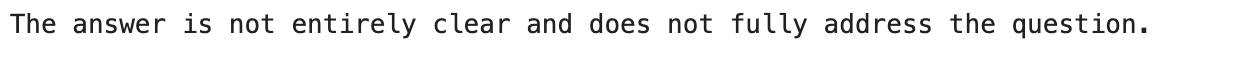

## Amateur-Expert Feedback Network

The `AmateurExpertFeedbackNetwork` orchestrates a collborative training and feedback mechanism between a studetn model and a teacher model to refine response evaluation through **knowledge distillation** and **feedback alignment**.

It is built to simulate how a less capable model can gradually emulate a stronger model in scoring and justifying answer quality through structured fine-tuning and semantic guidance.

**Key Components**

* Student Model: A smaller model that learns to evaluate answers through feedback

* Teacher Model: A stronger model that provides high-quality feedback as the supervision format.

* Expert Dataset: A collection of answer evaluations with scores and feedback for supervised fine-tuning


**Process**

`knowledge_distillation_with_SFT(...)`

Trains the student to:

* Minimize language modeling loss

* Match the expert score (score regression)

* Produce feedback semantically aligned with the teacher

* Align internal representation


`generate_combined_feedback(...)`

Generates a fused feedback score and message using:

* Student & Expert Evaluation

* Student Similarity Check (via BERTScore)

* If similarity is below a set threshold: there is a distillation loop

In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from bert_score import score as bert_score
import re
from difflib import SequenceMatcher


class AmateurExpertFeedbackNetWork:
    def __init__(self, student, teacher, expert_datasets=None, device=None, optimizer=None):
        self.student = student
        self.teacher = teacher
        self.expert_datasets = expert_datasets or []
        self.student_tokenizer = student.tokenizer
        self.teacher_tokenizer = teacher.tokenizer
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.optimizer = optimizer or AdamW(self.student.model.parameters(), lr=5e-5)
        self.align_hidden = None
        self.model_dtype = torch.float32
        self.last_score = 0.0

        for tokenizer in [self.student_tokenizer, self.teacher_tokenizer]:
            if tokenizer.pad_token is None:
                tokenizer.pad_token = tokenizer.eos_token

    def knowledge_distillation_with_SFT(self, epochs=3, stopped=60, warmup_alpha=False):
        score_loss_fn = nn.MSELoss()

        loss_history = {
            "lm_loss": [],
            "score_loss": [],
            "semantic_loss": [],
            "hidden_loss": [],
            "avg_loss_per_epoch": []
        }

        for epoch in range(epochs):
            print(f"\n--- Epoch {epoch + 1}/{epochs} ---")

            epoch_lm_loss = 0.0
            epoch_score_loss = 0.0
            epoch_semantic_loss = 0.0
            epoch_hidden_loss = 0.0
            num_samples = 0

            for i, expert_sample in enumerate(self.expert_datasets):
                if stopped is not None and i == stopped:
                    break

                prompt_text = expert_sample.get("prompt")
                answer = expert_sample.get("answer")
                expert_score = expert_sample.get("score")
                expert_feedback = expert_sample.get("feedback")

                if not prompt_text or not answer or expert_score is None:
                    continue

                print(f"\nSample {i + 1}")

                input_ids, labels, attention_mask = self.student.prepare_inputs_and_labels(
                    prompt_text, answer, expert_score, expert_feedback
                )

                student_out = self.student.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                    output_hidden_states=True,
                    return_dict=True
                )

                lm_loss = student_out.loss
                student_hidden = student_out.hidden_states[-1][:, 0, :]

                with torch.no_grad():
                    student_feedback, student_score = self.student.generate_feedback(prompt_text, answer)
                    teacher_feedback, teacher_score = self.teacher.generate_feedback(prompt_text, answer)
                    teacher_inputs = self.teacher_tokenizer(
                        prompt_text, return_tensors="pt", truncation=True, padding=True
                    ).to(self.device)
                    teacher_out = self.teacher.model(
                        input_ids=teacher_inputs["input_ids"],
                        attention_mask=teacher_inputs["attention_mask"],
                        output_hidden_states=True,
                        return_dict=True
                    )
                    teacher_hidden = teacher_out.hidden_states[-1][:, 0, :]

                student_hidden = student_hidden.to(self.model_dtype)
                teacher_hidden = teacher_hidden.to(self.model_dtype)

                if self.align_hidden is None:
                    student_dim = student_hidden.size(-1)
                    teacher_dim = teacher_hidden.size(-1)
                    self.align_hidden = (
                        nn.Linear(student_dim, teacher_dim).to(self.device).to(self.model_dtype)
                        if student_dim != teacher_dim else nn.Identity()
                    )

                student_aligned = self.align_hidden(student_hidden)
                cos_sim = nn.functional.cosine_similarity(student_aligned, teacher_hidden, dim=-1)
                hidden_loss = 1.0 - cos_sim.mean()

                student_score_tensor = torch.tensor([student_score], dtype=torch.float32, device=self.device)
                expert_score_tensor = torch.tensor([expert_score], dtype=torch.float32, device=self.device)
                score_loss = score_loss_fn(student_score_tensor, expert_score_tensor)

                P1, R1, F1 = bert_score([student_feedback], [teacher_feedback], lang="en", verbose=False)
                semantic_loss_expert = (1.0 - F1.to(self.device).to(self.model_dtype)).mean()

                # Weighted losses
                alpha = (epoch / epochs * 0.2) if warmup_alpha else 0.2
                beta, gamma, delta = 1.5, 2.0, 0.3
                total_loss = (
                    alpha * lm_loss +
                    beta * score_loss +
                    gamma * semantic_loss_expert +
                    delta * hidden_loss
                )

                self.optimizer.zero_grad()
                total_loss.backward()
                self.optimizer.step()

                epoch_lm_loss += lm_loss.item()
                epoch_score_loss += score_loss.item()
                epoch_semantic_loss += semantic_loss_expert.item()
                epoch_hidden_loss += hidden_loss.item()
                num_samples += 1

                # Print feedback comparison and loss
                print("---- FEEDBACK COMPARISON ----")
                print(f"[Student Feedback]: {student_feedback}")
                print(f"[Teacher Feedback]: {teacher_feedback}")
                print(f"[Expert Feedback]: {expert_feedback}")
                print("---- LOSS VALUES ----")
                print(f"LM Loss: {lm_loss.item():.4f}")
                print(f"Score Loss: {score_loss.item():.4f}")
                print(f"Semantic Loss: {semantic_loss_expert.item():.4f}")
                print(f"Hidden Loss: {hidden_loss.item():.4f}")
                print(f"TOTAL LOSS: {total_loss.item():.4f}")
                print("------------------------------\n")

            # Store average per-epoch losses
            if num_samples > 0:
                loss_history["lm_loss"].append(epoch_lm_loss / num_samples)
                loss_history["score_loss"].append(epoch_score_loss / num_samples)
                loss_history["semantic_loss"].append(epoch_semantic_loss / num_samples)
                loss_history["hidden_loss"].append(epoch_hidden_loss / num_samples)
                avg_loss = (
                    epoch_lm_loss + epoch_score_loss + epoch_semantic_loss + epoch_hidden_loss
                ) / (4 * num_samples)
            else:
                avg_loss = 0.0
                loss_history["lm_loss"].append(0.0)
                loss_history["score_loss"].append(0.0)
                loss_history["semantic_loss"].append(0.0)
                loss_history["hidden_loss"].append(0.0)

            loss_history["avg_loss_per_epoch"].append(avg_loss)
            print(f"\nEpoch {epoch + 1} average loss: {avg_loss:.4f}")

        # === Plot: Subplots for each loss trajectory ===
        import matplotlib.pyplot as plt

        loss_names = [
            ("Language Modeling Loss", "lm_loss", "blue"),
            ("Score Regression Loss", "score_loss", "green"),
            ("Semantic Loss (BERTScore)", "semantic_loss", "red"),
            ("Hidden Alignment Loss", "hidden_loss", "orange"),
            ("Total Loss", "avg_loss_per_epoch", "purple"),
        ]

        fig, axes = plt.subplots(nrows=len(loss_names), ncols=1, figsize=(8, 14))
        fig.suptitle("Loss Trajectories per Epoch", fontsize=16)

        for ax, (title, key, color) in zip(axes, loss_names):
            ax.plot(loss_history[key], marker="o", color=color)
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.grid(True)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        return self.teacher, self.student


    def generate_combined_feedback(
        self,
        prompt_text,
        answer,
        epochs=1,
        iterations=20,
        alpha=0.65,
        KD=True,
        max_distilled_attempts=1
    ):
        result = compute_all_losses_vectorized(
            prompt_text, answer,
            self.student, self.teacher,
            self.student_tokenizer, self.teacher_tokenizer,
            self.align_hidden, self.target_loss_values
        )

        student_feedback = result["student_feedback"]
        teacher_feedback = result["teacher_feedback"]
        student_score = result["student_score"]
        teacher_score = result["teacher_score"]

        if self.student.student_frozen:
            print("[Info] Student model already frozen. Skipping distillation.")
            return {
                "expert_feedback": teacher_feedback,
                "amateur_feedback": student_feedback,
                "combined_score": alpha * student_score + (1 - alpha) * teacher_score
            }


        if not result.get("meet_targets", False) and KD:
            print("[Distill Trigger] Student not meeting target losses. Initiating knowledge distillation...")
            print("Initial Loss vector:", result["loss_vector"].detach().cpu().numpy())
            print(f"Target Loss Values: {self.target_loss_values.detach().cpu().numpy()}")

            for attempt in range(max_distilled_attempts):
                print(f"[Distill Attempt {attempt + 1}] Training student via knowledge distillation...")
                self.knowledge_distillation_with_SFT(epochs=epochs, stopped=iterations)

                updated_result = compute_all_losses_vectorized(
                    prompt_text, answer,
                    self.student, self.teacher,
                    self.student_tokenizer, self.teacher_tokenizer,
                    self.align_hidden, self.target_loss_values
                )

                new_loss_vector = updated_result["loss_vector"].unsqueeze(0)

                if updated_result.get("meets_target", False):
                    print("[Pareto Achieved] Student meets target losses. Stopping early.")
                    student_feedback = updated_result["student_feedback"]
                    teacher_feedback = updated_result["teacher_feedback"]
                    student_score = updated_result["student_score"]
                    teacher_score = updated_result["teacher_score"]
                    self.student.freeze_student_model()
                    break
                else:
                    print("[DPM] Student has not reached the desired performance. Current loss vector:")
                    print(new_loss_vector.detach().cpu().numpy())

        elif result.get("meet_targets", False):
           print("[Status] Student has met target performance. Skipping knowledge distillation.")

        combined_score = alpha * student_score + (1 - alpha) * teacher_score

        return {
            "expert_feedback": teacher_feedback,
            "amateur_feedback": student_feedback,
            "combined_score": combined_score,
            "loss_vector": result["loss_vector"],
            "on_pareto_front": result.get("on_pareto_front", False),
        }

In [ ]:
network = AmateurExpertFeedbackNetWork(amateur_feedback_model, expert_model, expert_datasets)
expert_model.network = network

In [ ]:
test_prompt = "Why do you want to become a machine learning engineer?"
answer= expert_model.generate_answer(test_prompt)
print(answer)

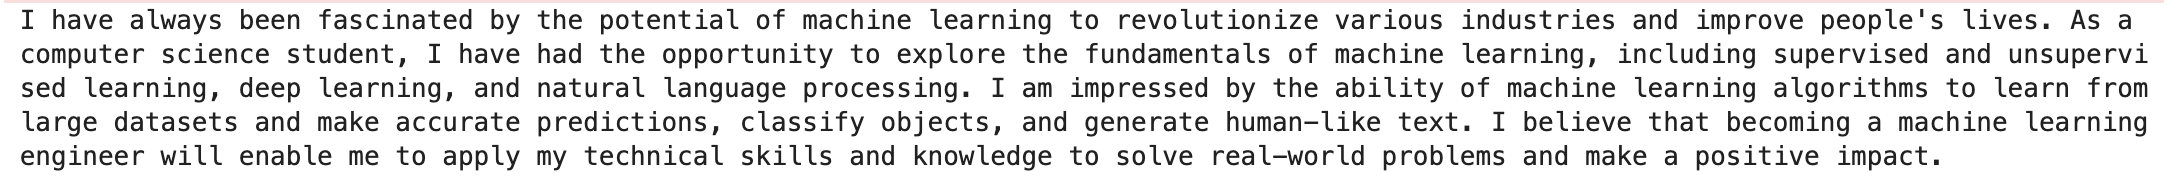

**Typically example iteration in KD**

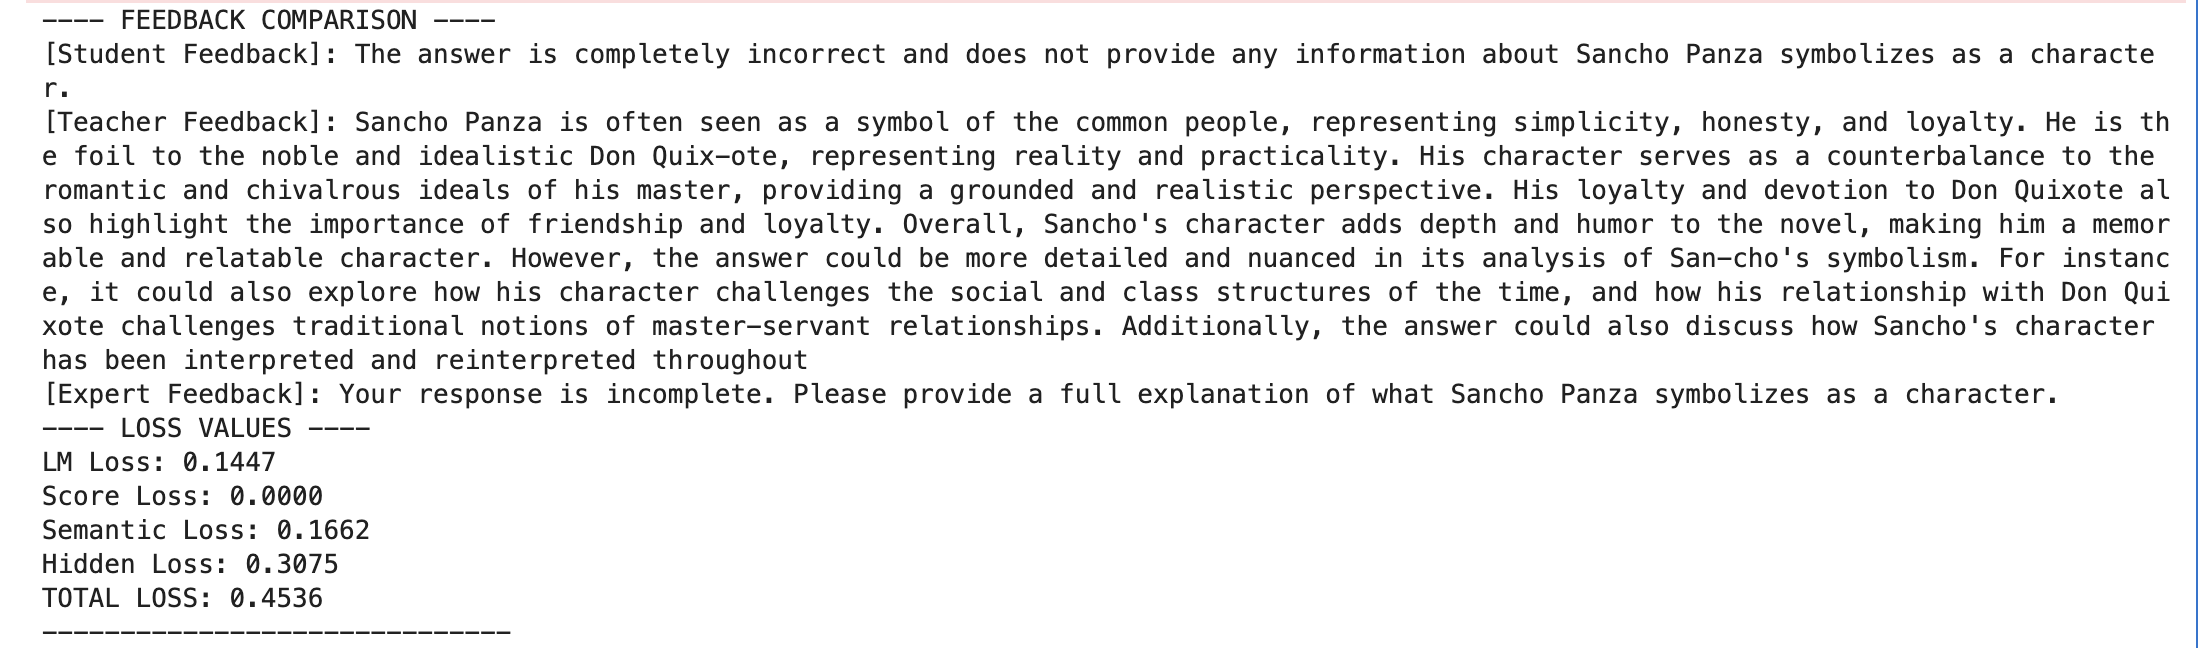

**Loss Graph**

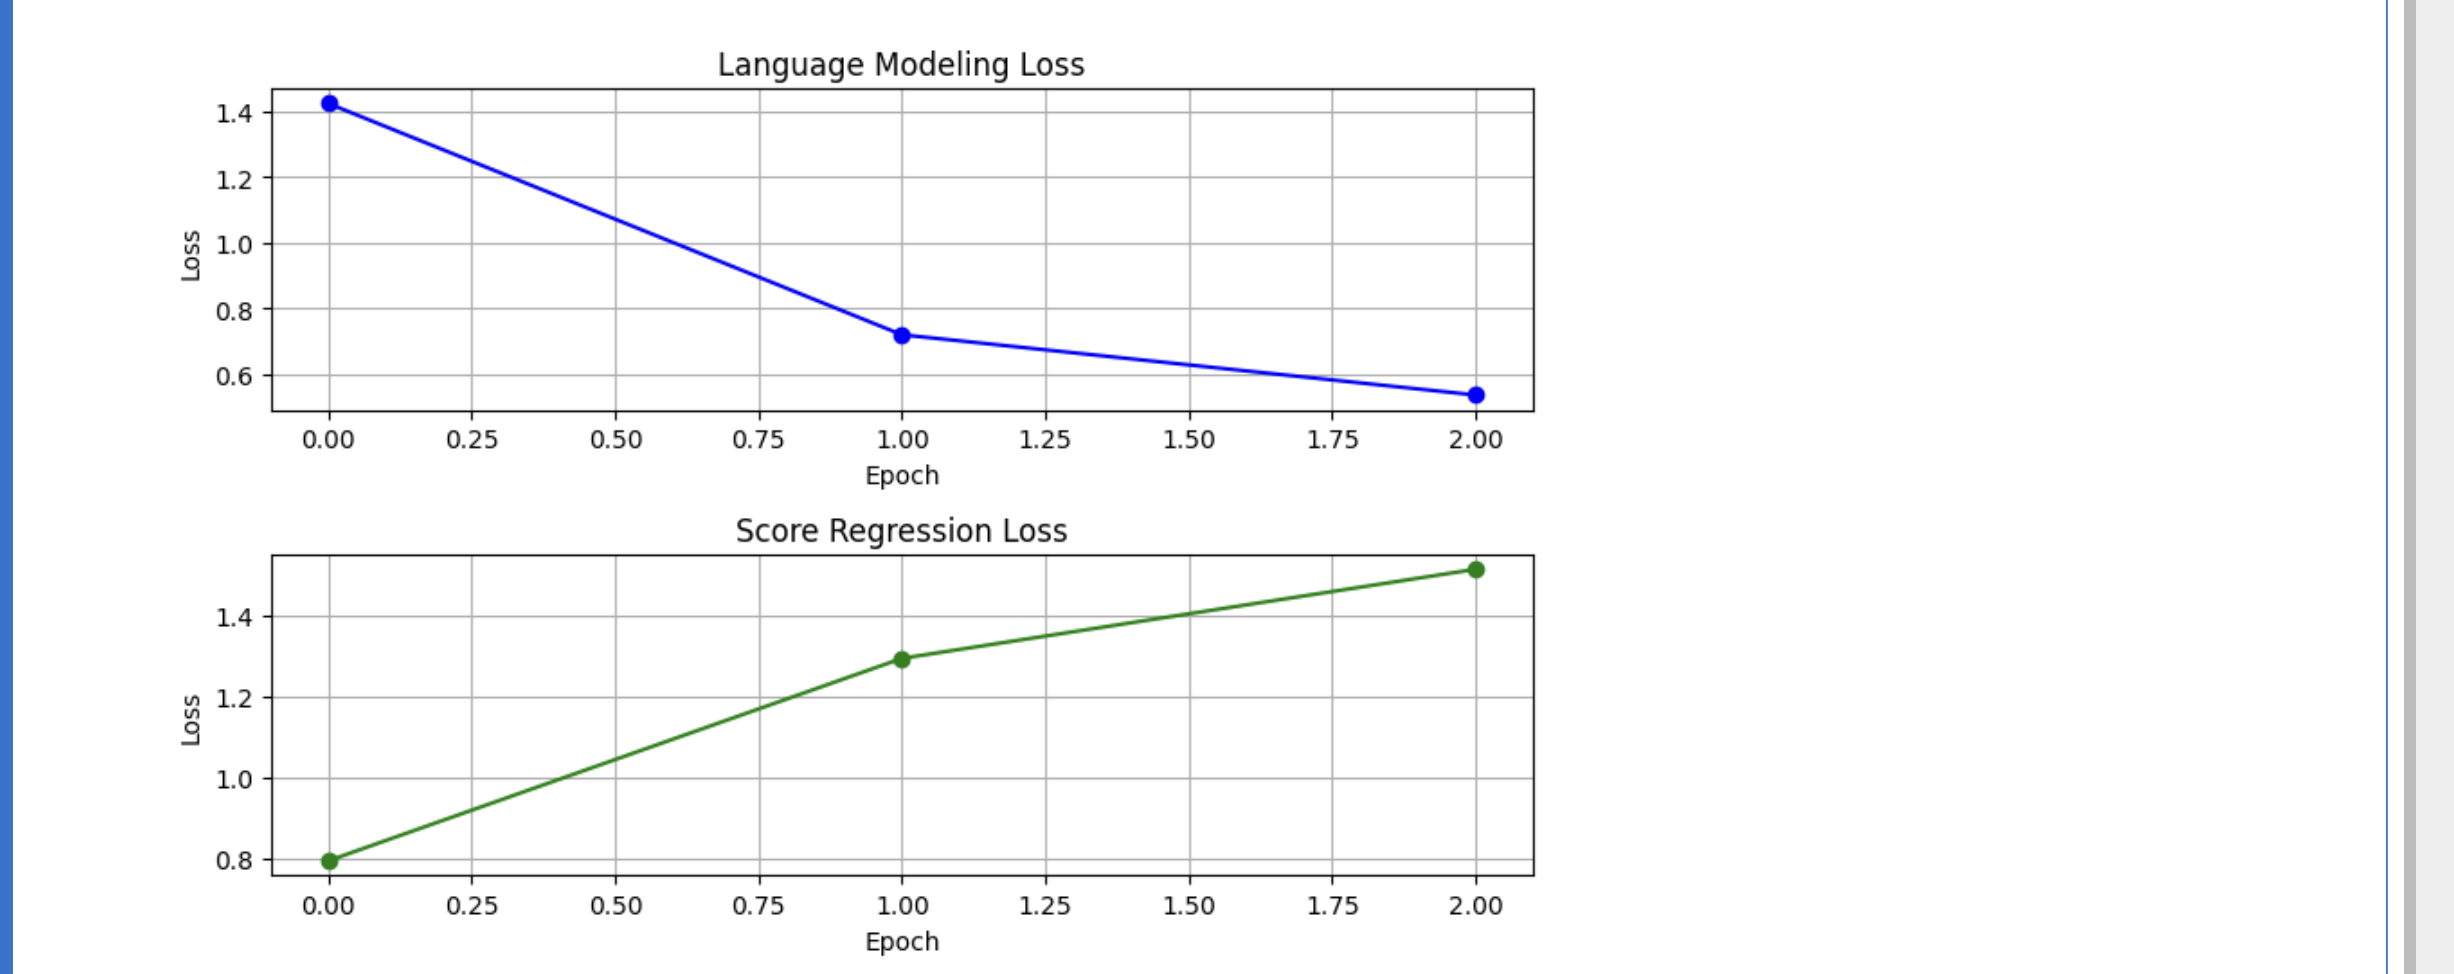

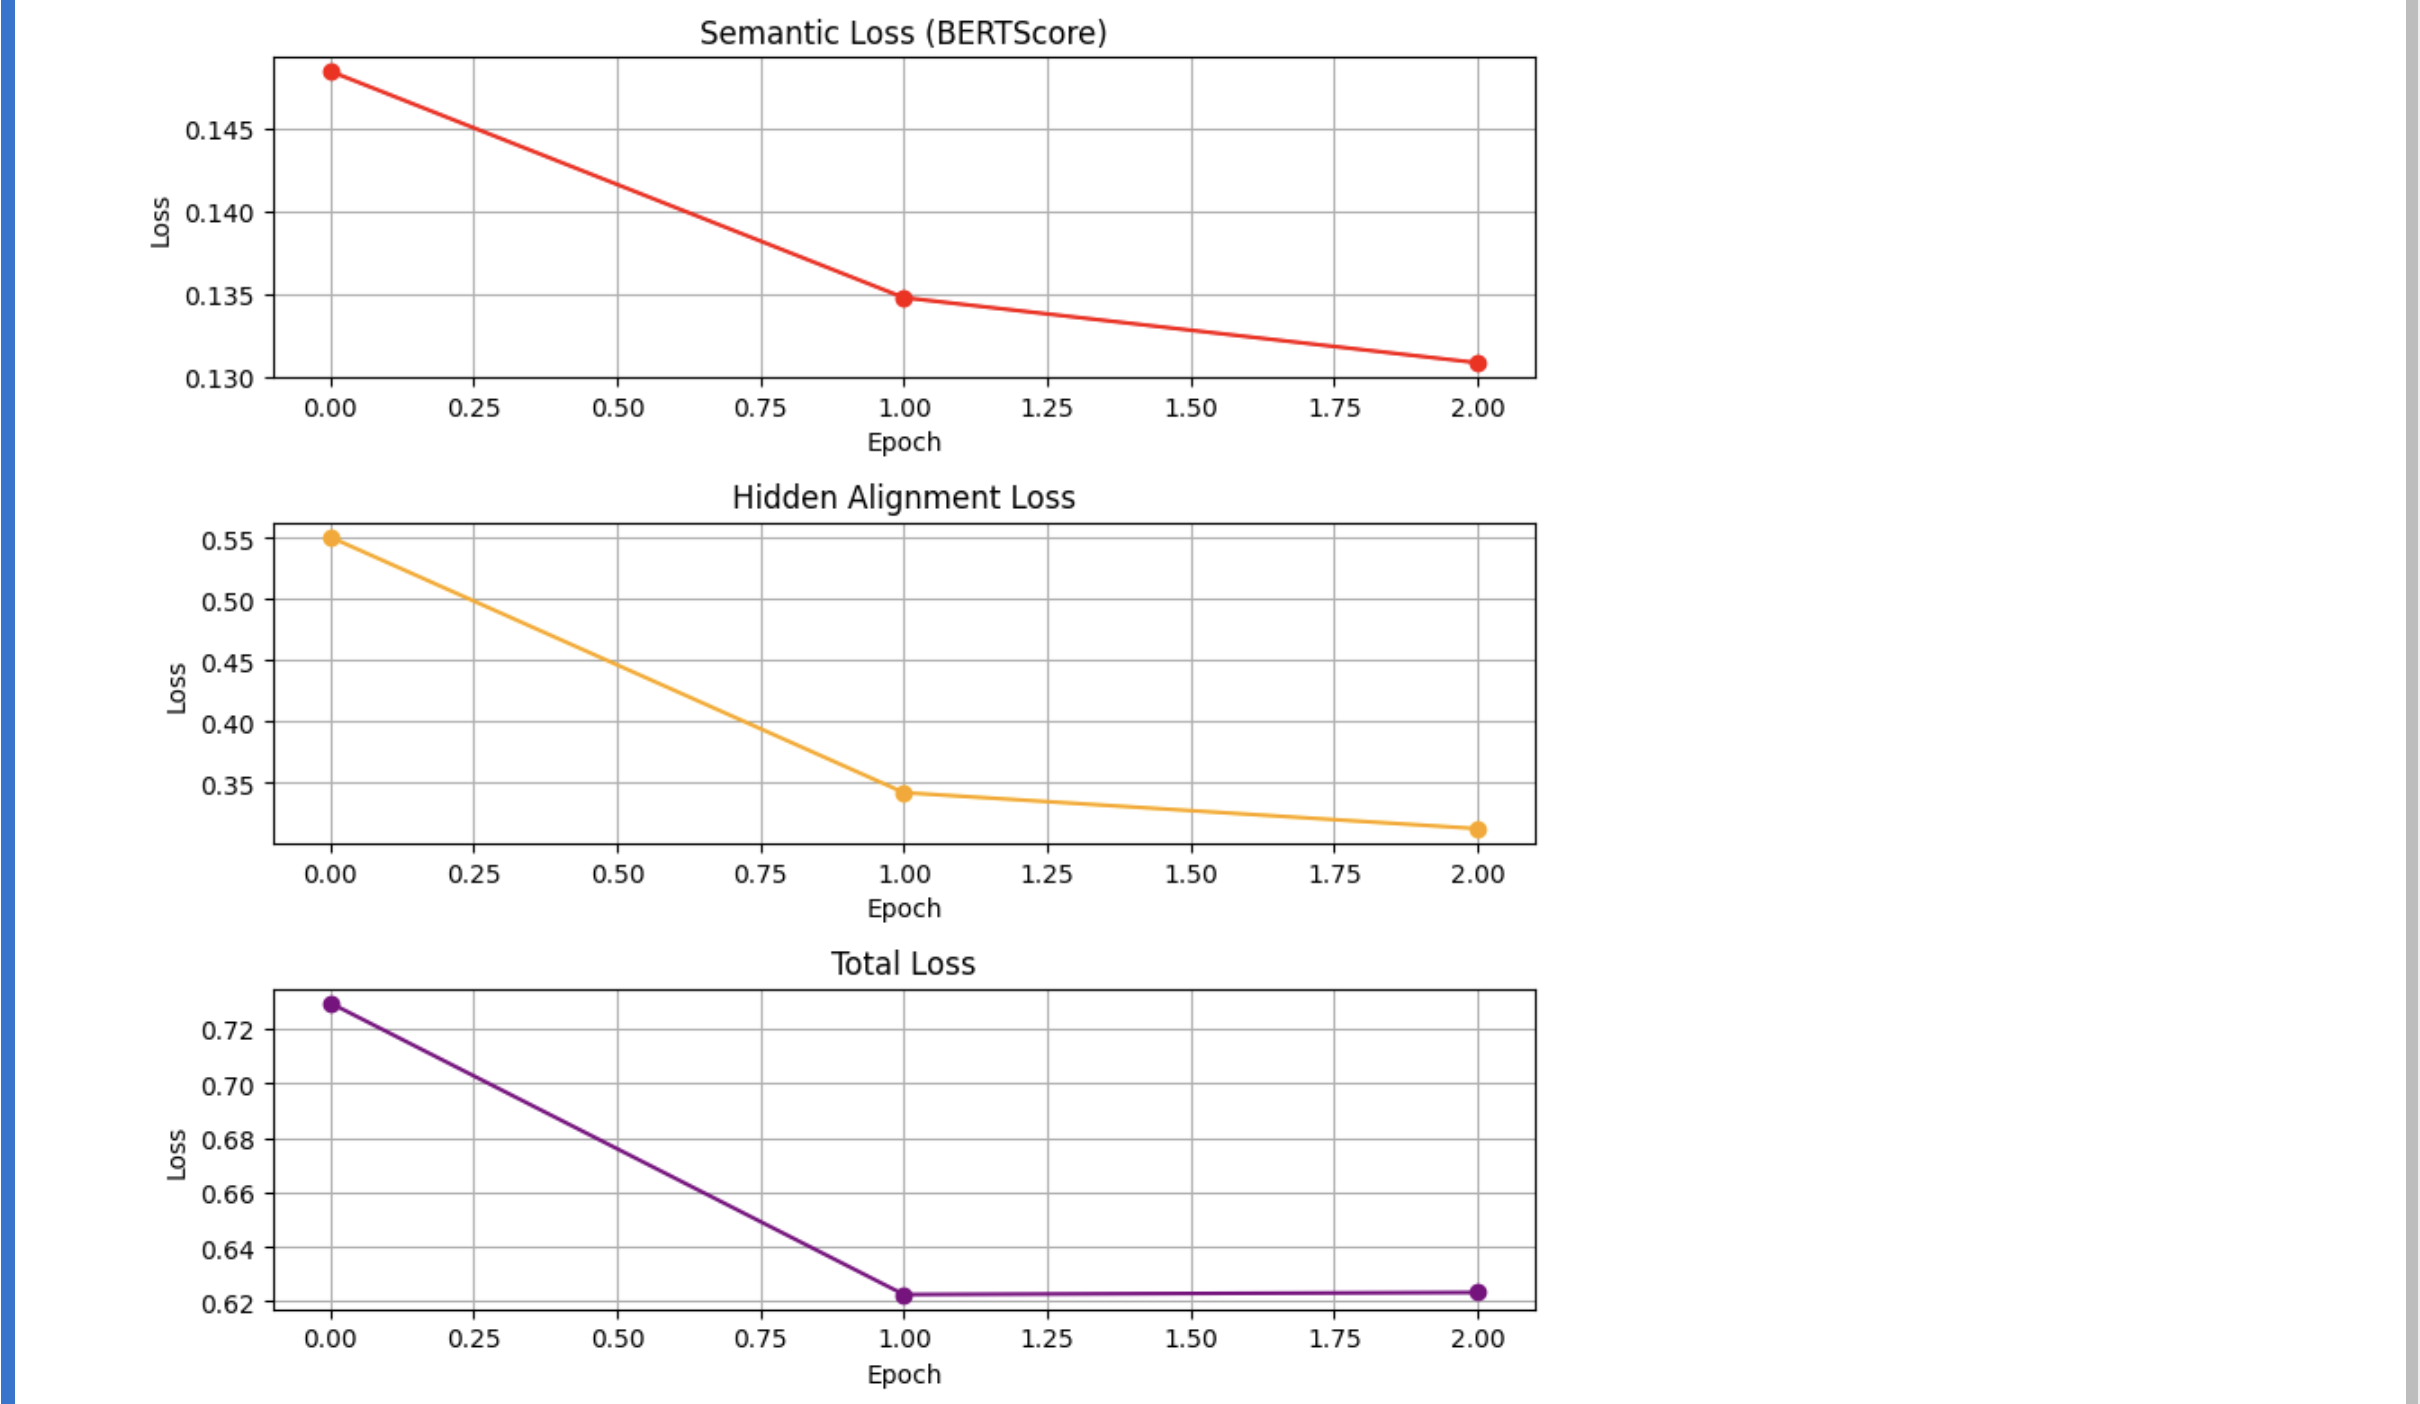

**Note**

**Condensed**:

The unified feedback derived by combining both the expert and amateur feedback. This reflects a consensus or merged perspective from both models.

**Improved**:
A revised answer generated after receiving the Condensed feedback. It incorporates suggestions from both expert and amateur critiques.

**Refined**:
A further enhanced version of the answer produced through self-critique, where the model reflects on its own previous response to iteratively improve clarity, correctness, or tone.

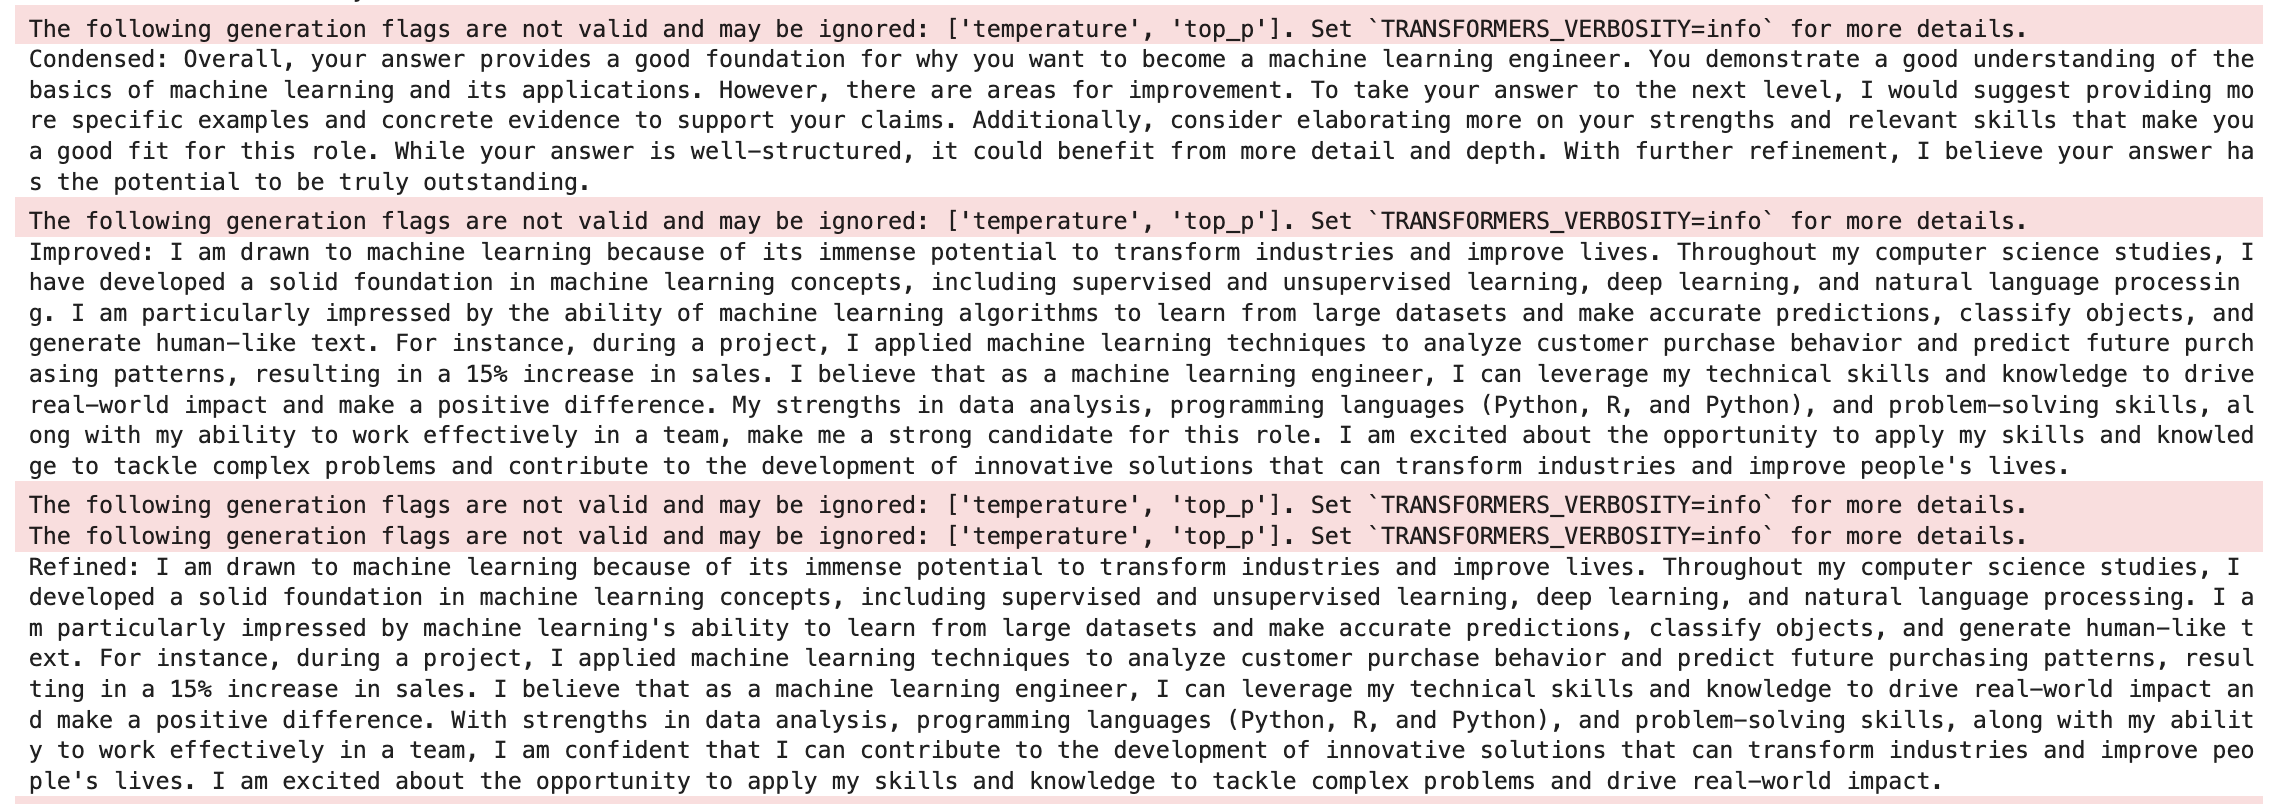

**Initial Bert Score**

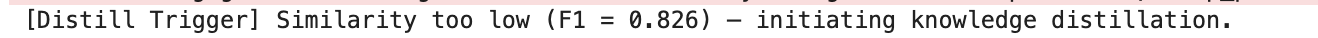

**Final Bert Score**

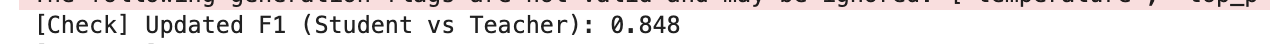

In [ ]:
answer, _, _ = expert_model.improve_answer_with_feedback_and_critique(test_prompt, answer)

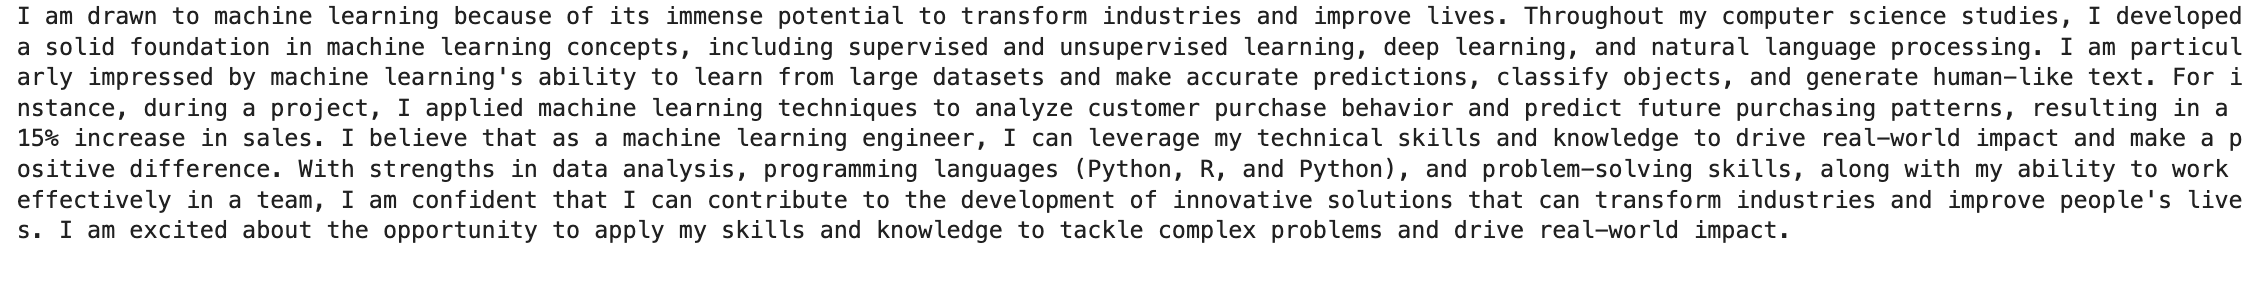